# F1 Podium Prediction: Data Cleaning

## 1. Setup and shared helpers

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def find_base():
    # Kaggle input folder or local folder
    hits = glob.glob("/kaggle/input/**/results.csv", recursive=True)
    if hits:
        return os.path.dirname(hits[0]) + "/"
    for cand in [os.environ.get("F1_DATA_DIR", ""), "original_data", "../original_data", "data"]:
        if cand and os.path.exists(os.path.join(cand, "results.csv")):
            return cand.rstrip("/\\") + "/"
    raise FileNotFoundError("results.csv not found: attach the F1 dataset or set F1_DATA_DIR")

BASE = find_base()
TABLE_NAMES = ["circuits", "constructors", "constructor_results", "constructor_standings",
               "drivers", "driver_standings", "races", "results", "qualifying",
               "lap_times", "pit_stops", "sprint_results", "seasons", "status"]

# load as text, convert explicitly later
raw_tables = {t: pd.read_csv(BASE + f"{t}.csv", dtype=str, keep_default_na=False)
              for t in TABLE_NAMES}          # raw copy, not modified

print("Dataset folder:", BASE)
pd.DataFrame({t: [len(df), df.shape[1]] for t, df in raw_tables.items()}, index=["rows", "cols"]).T

Dataset folder: original_data/


,rows,cols
circuits,77,9
constructors,212,5
constructor_results,12625,5
constructor_standings,13391,7
drivers,861,9
driver_standings,34863,7
races,1125,18
results,26759,18
qualifying,10494,9
lap_times,589081,6


### Shared helpers

In [2]:
SENTINELS = ["\\N", ""]

def is_text(col):
    # pandas 2 / pandas 3 text dtypes
    return col.dtype == object or pd.api.types.is_string_dtype(col.dtype)
cleaning_log, pk_reports, fk_reports = [], [], []
validation_reports, missing_notes, leakage_rows = [], [], []
SHARED = {}

def reset_reports():
    for lst in (cleaning_log, pk_reports, fk_reports, validation_reports, missing_notes, leakage_rows):
        lst.clear()
    SHARED.clear()

# sentinels
def replace_sentinels(df, table):
    # strip whitespace
    stripped = df.apply(lambda col: col.str.strip() if is_text(col) else col)
    n_ws = int((stripped != df).sum().sum())
    if n_ws:
        print(f"Whitespace trimmed in {table}: {n_ws} cells")
    df = stripped
    counts = df.isin(SENTINELS).sum()
    counts = counts[counts > 0]
    print(f"Sentinels replaced in {table}:", counts.to_dict() if len(counts) else "none")
    return df.replace(SENTINELS, np.nan), counts

def note_missing(table, column, kind, reason):
    missing_notes.append(dict(table=table, column=column, kind=kind, reason=reason))

# types
def to_numeric_cols(df, cols, table, kind="Int64"):
    for c in cols:
        conv = pd.to_numeric(df[c], errors="coerce")
        lost = int(df[c].notna().sum() - conv.notna().sum())
        if lost:
            print(f"  WARNING {table}.{c}: {lost} non-numeric values became NaN")
        df[c] = conv.astype("Int64") if kind == "Int64" else conv.astype(float)
    return df

def to_seconds(s):
    # 'm:ss.sss' -> seconds
    if pd.isna(s):
        return np.nan
    try:
        parts = [float(p) for p in str(s).strip().split(":")]
    except ValueError:
        return np.nan
    total = 0.0
    for p in parts:
        total = total * 60 + p
    return total

def parse_duration(series, label):
    parsed = series.map(to_seconds).astype(float)
    failed = series.notna() & parsed.isna()
    if failed.any():
        print(f"  WARNING {label}: {failed.sum()} unparseable values, e.g. {series[failed].unique()[:5]}")
    return parsed

# key checks
def check_pk(df, keys, table, kind="primary key"):
    pk_reports.append(dict(table=table, key=" + ".join(keys), kind=kind, rows=len(df),
                           null_keys=int(df[keys].isna().any(axis=1).sum()),
                           duplicate_keys=int(df.duplicated(keys).sum())))

def check_fk(tbls, child_table, col, parent_table, parent_col=None, report=None):
    parent_col = parent_col or col
    child = pd.to_numeric(tbls[child_table][col], errors="coerce")
    parent = pd.to_numeric(tbls[parent_table][parent_col], errors="coerce")
    orphans = child.notna() & ~child.isin(parent)
    (fk_reports if report is None else report).append(
        dict(child=f"{child_table}.{col}", parent=f"{parent_table}.{parent_col}",
             orphans=int(orphans.sum()), null_refs=int(child.isna().sum())))
    return orphans

# logs
def add_checks(table, checks):
    s = pd.Series({k: int(v) for k, v in checks.items()}, name="violations")
    for k, v in s.items():
        validation_reports.append(dict(table=table, check=k, violations=v))
    print(s.to_string())

def tag(table, availability, columns, note):
    for c in columns:
        leakage_rows.append(dict(table=table, column=c, availability=availability, note=note))

def log_step(step, table, before, after, reason):
    cleaning_log.append(dict(step=step, table=table, rows_before=before, rows_after=after,
                             removed=before - after, reason=reason))

def drop_races(tbls, race_ids, step, reason):
    # drop from all tables with raceId
    ids = set(pd.to_numeric(pd.Series(list(race_ids)), errors="coerce").dropna().astype(int))
    for name, df in tbls.items():
        if "raceId" in df.columns:
            before = len(df)
            tbls[name] = df[~pd.to_numeric(df["raceId"], errors="coerce").isin(ids)].reset_index(drop=True)
            if before != len(tbls[name]):
                log_step(step, name, before, len(tbls[name]), reason)
    return tbls

# eras
ERA_STARTS = {1958: "Rear-engine", 1966: "3L & wings", 1977: "Turbo", 1989: "Post-turbo",
              1995: "V10", 2009: "Late V8", 2014: "Hybrid", 2022: "Ground effect"}
ERA_BINS = [1949, 1957, 1965, 1976, 1988, 1994, 2008, 2013, 2021, 2100]
ERA_LABELS = ["1950–57", "1958–65", "1966–76", "1977–88", "1989–94",
              "1995–2008", "2009–13", "2014–21", "2022–24"]

def add_eras(ax):
    top = ax.get_ylim()[1]
    for y, label in ERA_STARTS.items():
        ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.6)
        ax.text(y + 0.4, top * 0.97, label, rotation=90, va="top", fontsize=7, color="grey")

def race_year(tbls):
    r = tbls["races"]
    return pd.Series(pd.to_numeric(r["year"]).astype(int).values, index=pd.to_numeric(r["raceId"]).astype(int))

## 2. Before-cleaning EDA

### 2.1 Placeholder values per table

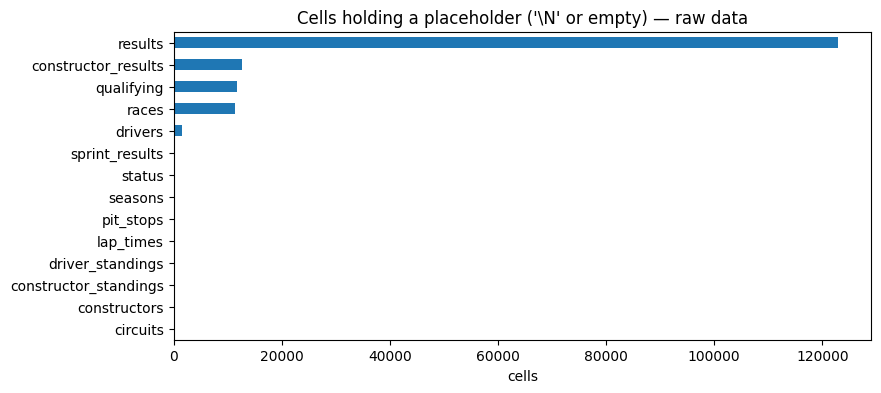

,placeholder cells per column
constructor_results,{'status': 12608}
drivers,"{'number': 802, 'code': 757}"
races,"{'time': 731, 'fp1_date': 1035, 'fp1_time': 10..."
results,"{'number': 6, 'position': 10953, 'time': 19079..."
qualifying,"{'q1': 156, 'q2': 4647, 'q3': 6865}"
sprint_results,"{'position': 15, 'time': 20, 'milliseconds': 2..."


In [3]:
sentinel_before = pd.Series({t: int(df.isin(SENTINELS).sum().sum()) for t, df in raw_tables.items()})
ax = sentinel_before.sort_values().plot(kind="barh", figsize=(9, 4), logx=False)
ax.set(title="Cells holding a placeholder ('\\N' or empty) — raw data", xlabel="cells")
plt.show()

per_col = {t: df.isin(SENTINELS).sum()[lambda s: s > 0].to_dict() for t, df in raw_tables.items()}
pd.Series({t: v for t, v in per_col.items() if v}, name="placeholder cells per column").to_frame()

### 2.2 Era profile: season length, field size, podium rate, qualifying coverage

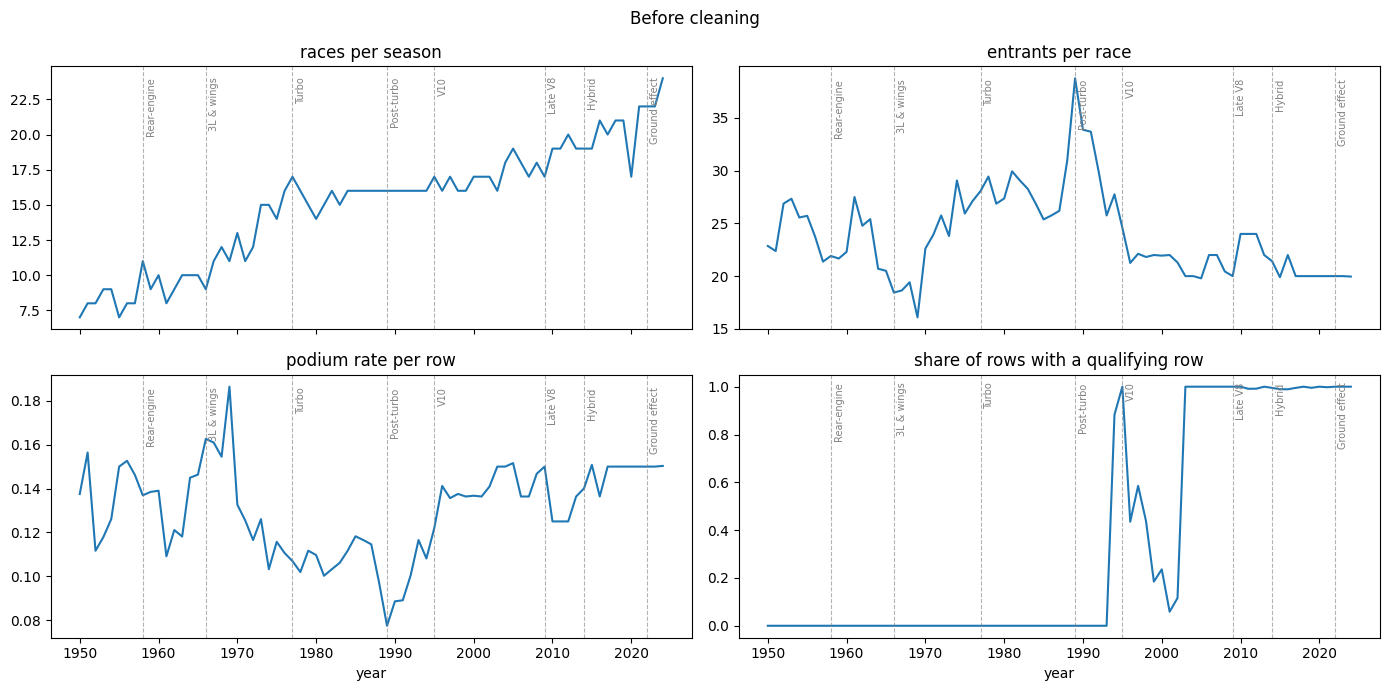

Overall podium rate (raw): 0.130 (mean of seasons)


,races,rows,podium_rate,quali_coverage,rows_per_race
era,,,,,
1950–57,64,1571,0.136,0.000,24.547
1958–65,77,1768,0.131,0.000,22.961
1966–76,139,3237,0.129,0.000,23.288
1977–88,188,5234,0.108,0.000,27.840
1989–94,96,3035,0.095,0.129,31.615
1995–2008,239,5138,0.140,0.652,21.498
2009–13,94,2150,0.131,0.996,22.872
2014–21,160,3267,0.147,0.995,20.419
2022–24,68,1359,0.150,1.000,19.985


In [4]:
def era_profile(tbls, title):
    res = pd.DataFrame({"raceId": pd.to_numeric(tbls["results"]["raceId"]),
                        "driverId": pd.to_numeric(tbls["results"]["driverId"]),
                        "positionOrder": pd.to_numeric(tbls["results"]["positionOrder"])})
    res["year"] = res["raceId"].map(race_year(tbls))
    res["podium"] = (res["positionOrder"] <= 3).astype(int)
    q = pd.DataFrame({"raceId": pd.to_numeric(tbls["qualifying"]["raceId"]),
                      "driverId": pd.to_numeric(tbls["qualifying"]["driverId"])}).drop_duplicates()
    res = res.merge(q.assign(has_quali=1), on=["raceId", "driverId"], how="left")
    res["has_quali"] = res["has_quali"].fillna(0)

    per_race = res.groupby("raceId").agg(year=("year", "first"), n=("driverId", "size"))
    by_year = pd.DataFrame({
        "races per season": per_race.groupby("year").size(),
        "entrants per race": per_race.groupby("year")["n"].mean(),
        "podium rate per row": res.groupby("year")["podium"].mean(),
        "share of rows with a qualifying row": res.groupby("year")["has_quali"].mean(),
    })
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
    for ax, col in zip(axes.ravel(), by_year.columns):
        by_year[col].plot(ax=ax); ax.set_title(col); add_eras(ax)
    fig.suptitle(title); plt.tight_layout(); plt.show()

    res["era"] = pd.cut(res["year"], bins=ERA_BINS, labels=ERA_LABELS)
    era = res.groupby("era", observed=True).agg(
        races=("raceId", "nunique"), rows=("raceId", "size"),
        podium_rate=("podium", "mean"), quali_coverage=("has_quali", "mean"))
    era["rows_per_race"] = era["rows"] / era["races"]
    return by_year, era.round(3)

before_year, before_era = era_profile(raw_tables, "Before cleaning")
print(f"Overall podium rate (raw): {before_year['podium rate per row'].mean():.3f} (mean of seasons)")
before_era

### 2.3 Duplicate driver–race rows in the raw results

176 rows in 85 duplicated (raceId, driverId) pairs


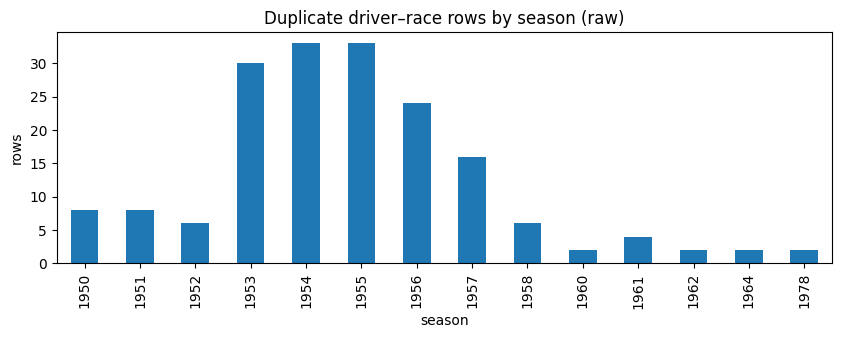

In [5]:
r_raw = raw_tables["results"]
dup_raw = r_raw[r_raw.duplicated(["raceId", "driverId"], keep=False)]
yr = race_year(raw_tables)
print(f"{len(dup_raw)} rows in {dup_raw[['raceId','driverId']].drop_duplicates().shape[0]} duplicated "
      f"(raceId, driverId) pairs")
ax = dup_raw["raceId"].astype(int).map(yr).value_counts().sort_index().plot(kind="bar", figsize=(10, 3))
ax.set(title="Duplicate driver–race rows by season (raw)", xlabel="season", ylabel="rows"); plt.show()

## 3. Value cleaning
### 3a. Races and timing tables

In [6]:
def clean_races(tbls):
    t = "races"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    session_cols = [c for c in df.columns if c.split("_")[0] in ("fp1", "fp2", "fp3", "quali", "sprint")]
    note_missing(t, "time", "unknown", "race start time not recorded before 2005")
    note_missing(t, "fp*/quali*/sprint* date & time", "structural",
                 "session schedule only recorded from 2021; empty sprint_* = no sprint that weekend")

    df = to_numeric_cols(df, ["raceId", "year", "round", "circuitId"], t)
    for c in ["date"] + [c for c in session_cols if c.endswith("_date")]:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    for c in ["time"] + [c for c in session_cols if c.endswith("_time")]:
        df[c] = pd.to_timedelta(df[c], errors="coerce")
    tbls[t] = df

    check_pk(df, ["raceId"], t)
    check_pk(df, ["year", "round"], t, kind="natural key")
    check_fk(tbls, t, "circuitId", "circuits")
    check_fk(tbls, t, "year", "seasons")

    rounds = df.groupby("year")["round"].agg(["min", "max", "count", "nunique"])
    date_order = df.sort_values(["year", "round"]).groupby("year")["date"].apply(lambda s: s.is_monotonic_increasing)
    result_ids = pd.to_numeric(tbls["results"]["raceId"], errors="coerce")
    add_checks(t, {
        "date year differs from year column": (df["date"].dt.year != df["year"]).sum(),
        "seasons with gaps/repeats in round numbers":
            ((rounds["min"] != 1) | (rounds["max"] != rounds["count"]) | (rounds["nunique"] != rounds["count"])).sum(),
        "seasons where round order differs from date order": (~date_order).sum(),
        "races with no result rows": (~df["raceId"].isin(result_ids)).sum(),
    })
    # match exact name, not circuit
    print(df[df["name"].str.contains("Indianapolis", case=False, na=False)]
            .groupby("name")["year"].agg(["min", "max", "count"]))
    SHARED["INDY_IDS"] = df.loc[df["name"] == "Indianapolis 500", "raceId"].tolist()

    tag(t, "identifier", ["raceId"], "key")
    tag(t, "pre-race", ["year", "round", "circuitId", "name", "date", "time"] + session_cols,
        "race calendar is known in advance")
    tag(t, "not used", ["url"], "reference link")
    return tbls

def clean_qualifying(tbls):
    t = "qualifying"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["qualifyId", "raceId", "driverId", "constructorId", "number", "position"], t)
    for c in ["q1", "q2", "q3"]:
        df[c] = parse_duration(df[c], f"{t}.{c}")
    tbls[t] = df

    year = df["raceId"].map(race_year(tbls))
    era = np.where(year >= 2006, "knockout (2006+)", "before 2006")
    print("Share of missing times by qualifying format:")
    print(df[["q1", "q2", "q3"]].isna().groupby(era).mean().round(3))
    note_missing(t, "q2/q3", "structural",
                 "before 2006 the session did not exist (Q2 only in the 2005 two-session format); "
                 "from 2006 the driver was eliminated earlier")
    note_missing(t, "q3 (top 10, 2006+)", "unknown", "reached Q3 (or Q3 not held) but no lap time")
    note_missing(t, "q1", "unknown", "no time set / not recorded (drivers start from the back)")

    check_pk(df, ["qualifyId"], t)
    check_pk(df, ["raceId", "driverId"], t, kind="grain")
    for col, parent in [("raceId", "races"), ("driverId", "drivers"), ("constructorId", "constructors")]:
        check_fk(tbls, t, col, parent)

    pos = df.groupby("raceId")["position"].agg(["min", "max", "count", "nunique"])
    gap_to_best = df["q1"] / df.groupby("raceId")["q1"].transform("min")
    add_checks(t, {
        "knockout-era top-10 without Q3 time": ((year >= 2006) & (df["position"] <= 10) & df["q3"].isna()).sum(),
        "races with gaps/repeats in qualifying position":
            ((pos["min"] != 1) | (pos["max"] != pos["count"]) | (pos["nunique"] != pos["count"])).sum(),
        "q1 outside 50-200 s": ((df["q1"] < 50) | (df["q1"] > 200)).sum(),
        "q1 more than 50% slower than session best": (gap_to_best > 1.5).sum(),
    })
    ax = gap_to_best.clip(upper=1.15).hist(bins=60, figsize=(9, 3))
    ax.set(title="Q1 time relative to the session's best (1.0 = fastest), clipped at 1.15"); plt.show()

    tag(t, "identifier", ["qualifyId"], "key")
    tag(t, "pre-race", ["raceId", "driverId", "constructorId", "number", "position", "q1", "q2", "q3"],
        "qualifying ends before the prediction cutoff")
    return tbls

def clean_lap_times(tbls):
    t = "lap_times"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    note_missing(t, "(whole table)", "structural", "lap-by-lap timing only exists from 1996")
    df = to_numeric_cols(df, ["raceId", "driverId", "lap", "position", "milliseconds"], t)
    df["time"] = parse_duration(df["time"], f"{t}.time")
    tbls[t] = df

    check_pk(df, ["raceId", "driverId", "lap"], t)
    check_fk(tbls, t, "raceId", "races"); check_fk(tbls, t, "driverId", "drivers")
    laps = df.groupby(["raceId", "driverId"])["lap"].agg(["min", "max", "count"])
    race_median = df.groupby("raceId")["time"].transform("median")
    add_checks(t, {
        "parsed time differs from milliseconds by > 0.01 s": ((df["time"] - df["milliseconds"] / 1000).abs() > 0.01).sum(),
        "lap number < 1": (df["lap"] < 1).sum(),
        "driver-races with missing laps": ((laps["min"] != 1) | (laps["max"] != laps["count"])).sum(),
        "non-positive lap time": (df["time"] <= 0).sum(),
        "laps > 3x race median (safety car / red flag, kept)": (df["time"] > 3 * race_median).sum(),
    })
    tag(t, "post-race", list(df.columns), "recorded during the race; usable only from PREVIOUS races")
    return tbls

def clean_pit_stops(tbls):
    t = "pit_stops"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    note_missing(t, "(whole table)", "structural", "pit-stop data only exists from 2011")
    df = to_numeric_cols(df, ["raceId", "driverId", "stop", "lap", "milliseconds"], t)
    df["time"] = pd.to_timedelta(df["time"], errors="coerce")
    df["duration"] = parse_duration(df["duration"], f"{t}.duration")
    tbls[t] = df

    check_pk(df, ["raceId", "driverId", "stop"], t)
    check_fk(tbls, t, "raceId", "races"); check_fk(tbls, t, "driverId", "drivers")
    stops = df.groupby(["raceId", "driverId"])["stop"].agg(["min", "max", "count"])
    add_checks(t, {
        "duration differs from milliseconds by > 0.01 s": ((df["duration"] - df["milliseconds"] / 1000).abs() > 0.01).sum(),
        "driver-races with gaps in stop numbers": ((stops["min"] != 1) | (stops["max"] != stops["count"])).sum(),
        "lap < 1": (df["lap"] < 1).sum(),
        "stops longer than 60 s (red flag / repairs, kept)": (df["duration"] > 60).sum(),
    })
    ax = df["duration"].clip(upper=60).hist(bins=60, figsize=(9, 3))
    ax.set(title="Pit-stop duration (s), clipped at 60"); plt.show()
    tag(t, "post-race", list(df.columns), "recorded during the race; usable only from PREVIOUS races")
    return tbls

STANDING_PARENT = {"driverId": "drivers", "constructorId": "constructors"}

def clean_standings(tbls, t, entity, pk):
    print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, [pk, "raceId", entity, "position", "wins"], t)
    df = to_numeric_cols(df, ["points"], t, kind="float")
    tbls[t] = df

    check_pk(df, [pk], t)
    check_pk(df, ["raceId", entity], t, kind="grain")
    check_fk(tbls, t, "raceId", "races"); check_fk(tbls, t, entity, STANDING_PARENT[entity])

    meta = tbls["races"].set_index("raceId")[["year", "round"]]
    s = df.join(meta, on="raceId").sort_values([entity, "year", "round"])
    g = s.groupby([entity, "year"])
    add_checks(t, {
        "points decrease within a season": (g["points"].diff() < 0).sum(),
        "wins decrease within a season": (g["wins"].diff() < 0).sum(),
        "wins greater than round number": (s["wins"] > s["round"]).sum(),
        "negative points": (s["points"] < 0).sum(),
    })
    odd = s.loc[~s["positionText"].astype(str).str.fullmatch(r"\d+"), "positionText"]
    print("Non-numeric positionText codes:", odd.value_counts().to_dict())

    tag(t, "identifier", [pk], "key")
    tag(t, "post-race", ["points", "position", "positionText", "wins"],
        "standings AFTER this race: shift to the previous round before using as a feature")
    return tbls

def clean_constructor_results(tbls):
    t = "constructor_results"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    note_missing(t, "status", "structural", "only filled ('D') when the constructor was disqualified")
    print("status values:", df["status"].value_counts(dropna=False).to_dict())
    df = to_numeric_cols(df, ["constructorResultsId", "raceId", "constructorId"], t)
    df = to_numeric_cols(df, ["points"], t, kind="float")
    tbls[t] = df

    check_pk(df, ["constructorResultsId"], t)
    check_pk(df, ["raceId", "constructorId"], t, kind="grain")
    check_fk(tbls, t, "raceId", "races"); check_fk(tbls, t, "constructorId", "constructors")
    add_checks(t, {"negative points": (df["points"] < 0).sum()})
    tag(t, "identifier", ["constructorResultsId"], "key")
    tag(t, "post-race", ["points", "status"], "this race's constructor points: usable only from PREVIOUS races")
    return tbls

def clean_race_family(tbls):
    tbls = clean_races(tbls)
    tbls = clean_qualifying(tbls)
    tbls = clean_lap_times(tbls)
    tbls = clean_pit_stops(tbls)
    tbls = clean_standings(tbls, "driver_standings", "driverId", "driverStandingsId")
    tbls = clean_standings(tbls, "constructor_standings", "constructorId", "constructorStandingsId")
    tbls = clean_constructor_results(tbls)
    return tbls

### 3b. Results family and lookup tables

In [7]:
RESULT_INT = ["resultId", "raceId", "driverId", "constructorId", "number", "grid", "position",
              "positionOrder", "laps", "milliseconds", "fastestLap", "rank", "statusId"]

def clean_result_table(tbls, t):
    # results + sprint_results
    print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, [c for c in RESULT_INT if c in df.columns], t)
    df = to_numeric_cols(df, [c for c in ["points", "fastestLapSpeed"] if c in df.columns], t, kind="float")
    df["fastestLapTime"] = parse_duration(df["fastestLapTime"], f"{t}.fastestLapTime")
    # time kept as text
    tbls[t] = df

    note_missing(t, "position", "structural", "empty when the driver was not classified (positionText is a letter)")
    note_missing(t, "time / milliseconds", "structural", "only recorded for drivers who finished on the lead lap")
    note_missing(t, "fastestLap* / rank", "structural", "fastest-lap data only recorded from 2004")
    if t == "results":
        note_missing(t, "number", "unknown", "car number not recorded for a handful of old entries")

    check_pk(df, ["resultId"], t)
    check_pk(df, ["raceId", "driverId"], t, kind="grain (fixed in Part 4.3)")
    for col, parent in [("raceId", "races"), ("driverId", "drivers"),
                        ("constructorId", "constructors"), ("statusId", "status")]:
        check_fk(tbls, t, col, parent)

    num_text = df["positionText"].str.fullmatch(r"\d+")
    pos_from_text = pd.to_numeric(df["positionText"].where(num_text), errors="coerce")
    per_race = df.groupby("raceId")["positionOrder"].agg(["min", "max", "count", "nunique"])
    add_checks(t, {
        "grid < 0": (df["grid"] < 0).sum(),
        "laps < 0": (df["laps"] < 0).sum(),
        "points < 0": (df["points"] < 0).sum(),
        "positionOrder < 1": (df["positionOrder"] < 1).sum(),
        "races with gaps/repeats in positionOrder (raw)":
            ((per_race["min"] != 1) | (per_race["max"] != per_race["count"]) | (per_race["nunique"] != per_race["count"])).sum(),
        "position null but positionText numeric": (df["position"].isna() & num_text).sum(),
        "position filled but positionText a letter": (df["position"].notna() & ~num_text).sum(),
        "position differs from positionText": (df["position"].notna() & num_text & (df["position"] != pos_from_text)).sum(),
        "classified position differs from positionOrder": (df["position"].notna() & (df["position"] != df["positionOrder"])).sum(),
    })

    tag(t, "identifier", ["resultId", "raceId", "driverId"], "keys")
    if t == "results":
        tag(t, "pre-race", ["constructorId", "number", "grid"], "known once the starting grid is set")
        tag(t, "target", ["positionOrder"], "podium label = positionOrder <= 3; never a feature")
        tag(t, "post-race", ["position", "positionText", "points", "laps", "time", "milliseconds",
                             "fastestLap", "rank", "fastestLapTime", "fastestLapSpeed", "statusId"],
            "outcome of this race: LEAKAGE if used for the same race")
    else:
        tag(t, "pre-race (team decision)", [c for c in df.columns if c not in ("resultId", "raceId", "driverId")],
            "the sprint (2021+) runs BEFORE the main race, so its result is known at the cutoff")
    return tbls

def clean_drivers(tbls):
    t = "drivers"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["driverId", "number"], t)
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
    tbls[t] = df
    note_missing(t, "number / code", "structural", "permanent numbers (2014) and 3-letter codes only exist for modern drivers")
    check_pk(df, ["driverId"], t)
    add_checks(t, {
        "dob missing or unparseable": df["dob"].isna().sum(),
        "duplicate driverRef": df["driverRef"].duplicated().sum(),
        "same forename + surname + dob under two ids": df.duplicated(["forename", "surname", "dob"]).sum(),
        "nationality missing": df["nationality"].isna().sum(),
    })
    tag(t, "identifier", ["driverId", "driverRef"], "keys")
    tag(t, "pre-race", ["dob", "nationality"], "static driver facts")
    tag(t, "not used", ["number", "code", "forename", "surname", "url"], "labels / links")
    return tbls

def clean_circuits(tbls):
    t = "circuits"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["circuitId"], t)
    df = to_numeric_cols(df, ["lat", "lng", "alt"], t, kind="float")
    tbls[t] = df
    check_pk(df, ["circuitId"], t)
    add_checks(t, {
        "duplicate circuitRef": df["circuitRef"].duplicated().sum(),
        "latitude outside [-90, 90]": (~df["lat"].between(-90, 90)).sum(),
        "longitude outside [-180, 180]": (~df["lng"].between(-180, 180)).sum(),
        "country missing": df["country"].isna().sum(),
    })
    tag(t, "identifier", ["circuitId", "circuitRef"], "keys")
    tag(t, "pre-race", ["name", "location", "country", "lat", "lng", "alt"], "static circuit facts")
    tag(t, "not used", ["url"], "reference link")
    return tbls

def clean_constructors(tbls):
    t = "constructors"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["constructorId"], t)
    tbls[t] = df
    check_pk(df, ["constructorId"], t)
    add_checks(t, {"duplicate constructorRef": df["constructorRef"].duplicated().sum(),
                   "duplicate name": df["name"].duplicated().sum()})
    tag(t, "identifier", ["constructorId", "constructorRef"], "keys (renamed teams get new ids)")
    tag(t, "pre-race", ["name", "nationality"], "static team facts")
    tag(t, "not used", ["url"], "reference link")
    return tbls

def clean_seasons(tbls):
    t = "seasons"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["year"], t)
    tbls[t] = df
    check_pk(df, ["year"], t)
    tag(t, "identifier", ["year"], "key"); tag(t, "not used", ["url"], "reference link")
    return tbls

def clean_status(tbls):
    t = "status"; print(f"\n=== {t} ===")
    df, _ = replace_sentinels(tbls[t], t)
    df = to_numeric_cols(df, ["statusId"], t)
    tbls[t] = df
    check_pk(df, ["statusId"], t)
    add_checks(t, {"duplicate status text": df["status"].duplicated().sum()})
    tag(t, "post-race", ["status"], "why a race ended: post-race (used only for data-engineering Q3)")
    return tbls

def clean_results_family(tbls):
    for f in (clean_drivers, clean_circuits, clean_constructors, clean_seasons, clean_status):
        tbls = f(tbls)
    tbls = clean_result_table(tbls, "results")
    tbls = clean_result_table(tbls, "sprint_results")
    return tbls

### 3c. Running the value cleaning


=== races ===


Sentinels replaced in races: {'time': 731, 'fp1_date': 1035, 'fp1_time': 1057, 'fp2_date': 1035, 'fp2_time': 1057, 'fp3_date': 1053, 'fp3_time': 1072, 'quali_date': 1035, 'quali_time': 1057, 'sprint_date': 1107, 'sprint_time': 1110}
date year differs from year column                   0
seasons with gaps/repeats in round numbers           0
seasons where round order differs from date order    0
races with no result rows                            0
                   min   max  count
name                               
Indianapolis 500  1950  1960     11

=== qualifying ===
Sentinels replaced in qualifying: {'q1': 156, 'q2': 4647, 'q3': 6865}
Share of missing times by qualifying format:
                     q1     q2    q3
before 2006       0.031  0.959  1.00
knockout (2006+)  0.010  0.272  0.54
knockout-era top-10 without Q3 time               123
races with gaps/repeats in qualifying position      0
q1 outside 50-200 s                                 1
q1 more than 50% slower than se

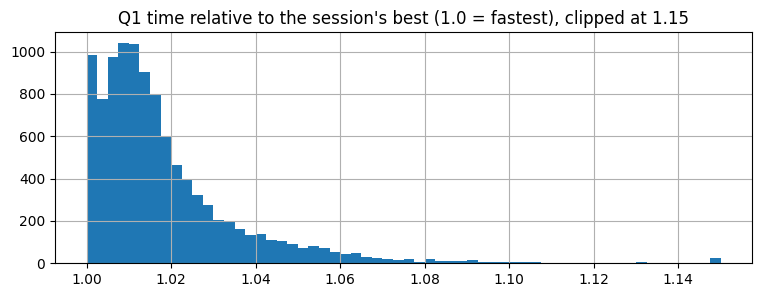


=== lap_times ===
Sentinels replaced in lap_times: none
parsed time differs from milliseconds by > 0.01 s        0
lap number < 1                                           0
driver-races with missing laps                           0
non-positive lap time                                    0
laps > 3x race median (safety car / red flag, kept)    723

=== pit_stops ===
Sentinels replaced in pit_stops: none
duration differs from milliseconds by > 0.01 s         0
driver-races with gaps in stop numbers                 8
lap < 1                                                0
stops longer than 60 s (red flag / repairs, kept)    517


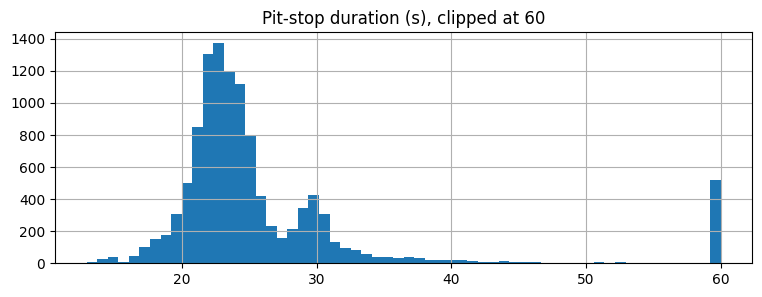


=== driver_standings ===
Sentinels replaced in driver_standings: none
points decrease within a season    0
wins decrease within a season      0
wins greater than round number     0
negative points                    0
Non-numeric positionText codes: {'D': 1}

=== constructor_standings ===
Sentinels replaced in constructor_standings: none
points decrease within a season    2
wins decrease within a season      0
wins greater than round number     0
negative points                    0
Non-numeric positionText codes: {'E': 17}

=== constructor_results ===
Sentinels replaced in constructor_results: {'status': 12608}
status values: {nan: 12608, 'D': 17}
negative points    0

=== drivers ===
Whitespace trimmed in drivers: 1 cells
Sentinels replaced in drivers: {'number': 802, 'code': 757}
dob missing or unparseable                     0
duplicate driverRef                            0
same forename + surname + dob under two ids    0
nationality missing                            0

=== circ

,table,key,kind,rows,null_keys,duplicate_keys
0,races,raceId,primary key,1125,0,0
1,races,year + round,natural key,1125,0,0
2,qualifying,qualifyId,primary key,10494,0,0
3,qualifying,raceId + driverId,grain,10494,0,0
4,lap_times,raceId + driverId + lap,primary key,589081,0,0
5,pit_stops,raceId + driverId + stop,primary key,11371,0,0
6,driver_standings,driverStandingsId,primary key,34863,0,0
7,driver_standings,raceId + driverId,grain,34863,0,0
8,constructor_standings,constructorStandingsId,primary key,13391,0,0
9,constructor_standings,raceId + constructorId,grain,13391,0,0


,child,parent,orphans,null_refs
0,races.circuitId,circuits.circuitId,0,0
1,races.year,seasons.year,0,0
2,qualifying.raceId,races.raceId,0,0
3,qualifying.driverId,drivers.driverId,0,0
4,qualifying.constructorId,constructors.constructorId,0,0
5,lap_times.raceId,races.raceId,0,0
6,lap_times.driverId,drivers.driverId,0,0
7,pit_stops.raceId,races.raceId,0,0
8,pit_stops.driverId,drivers.driverId,0,0
9,driver_standings.raceId,races.raceId,0,0


In [8]:
reset_reports()
tables = {t: df.copy() for t, df in raw_tables.items()}
tables = clean_race_family(tables)
tables = clean_results_family(tables)

value_clean = {t: df.copy() for t, df in tables.items()}   # snapshot before row removal

# exact duplicates and repeated keys
for t in TABLE_NAMES:
    before = len(tables[t])
    tables[t] = tables[t].drop_duplicates().reset_index(drop=True)
    if len(tables[t]) != before:
        log_step("0_exact_duplicates", t, before, len(tables[t]), "fully identical rows")
for t, key in {"lap_times": ["raceId", "driverId", "lap"], "pit_stops": ["raceId", "driverId", "stop"]}.items():
    before = len(tables[t])
    tables[t] = tables[t].drop_duplicates(key, keep="first").reset_index(drop=True)
    if len(tables[t]) != before:
        log_step("0_key_duplicates", t, before, len(tables[t]), f"repeated {' + '.join(key)}: first record kept")
print("Duplicate records removed:", pd.DataFrame(cleaning_log).to_dict("records") if cleaning_log else "none")

pk_df, fk_df = pd.DataFrame(pk_reports), pd.DataFrame(fk_reports)
print(f"\nPrimary keys checked: {len(pk_df)} | foreign keys checked: {len(fk_df)} | "
      f"orphans found: {int(fk_df['orphans'].sum())}")
display(pk_df)
display(fk_df)

## 4. Row cleaning

### 4.1 Exclude the Indianapolis 500 from every table

In [9]:
tables = drop_races(tables, SHARED["INDY_IDS"], "1_indy500", "Indianapolis 500 excluded")
print("Indianapolis 500 races removed:", len(SHARED["INDY_IDS"]))
display(pd.DataFrame(cleaning_log))

Indianapolis 500 races removed: 11


,step,table,rows_before,rows_after,removed,reason
0,1_indy500,constructor_results,12625,12604,21,Indianapolis 500 excluded
1,1_indy500,constructor_standings,13391,13365,26,Indianapolis 500 excluded
2,1_indy500,driver_standings,34863,34194,669,Indianapolis 500 excluded
3,1_indy500,races,1125,1114,11,Indianapolis 500 excluded
4,1_indy500,results,26759,26354,405,Indianapolis 500 excluded


### 4.2 Remove non-starters (did not qualify / pre-qualify / withdrew)

In [10]:
res = tables["results"]
status_name = res["statusId"].map(tables["status"].set_index("statusId")["status"])
year = res["raceId"].map(race_year(tables))
grid0 = res["grid"] == 0

print("Share of rows with grid = 0 by decade:")
print(grid0.groupby((year // 10) * 10).mean().mul(100).round(1).rename("% grid 0").to_frame().T)
print("\nStatus of grid = 0 rows:"); print(status_name[grid0].value_counts().head(12))
print("\npositionText of grid = 0 rows:"); print(res.loc[grid0, "positionText"].value_counts().head(8))

cand = tables["status"][tables["status"]["status"].str.contains("qualif|withdr|107", case=False)]
print("\nCandidate non-starter statuses (searched in the data, not typed by hand):")
print(cand.assign(rows=cand["statusId"].map(res["statusId"].value_counts()).fillna(0).astype(int)))

Share of rows with grid = 0 by decade:
raceId    1950  1960  1970  1980  1990  2000  2010  2020
% grid 0   4.2   9.5   9.2  12.7   8.4   0.2   0.7   2.7

Status of grid = 0 rows:
statusId
Did not qualify       1013
Did not prequalify     331
Withdrew               164
+1 Lap                  27
Finished                22
Accident                20
Injury                   8
+2 Laps                  7
Engine                   6
Excluded                 6
Disqualified             6
Collision damage         3
Name: count, dtype: int64

positionText of grid = 0 rows:
positionText
F     1348
W      203
R       14
17       9
13       7
E        7
10       7
15       6
Name: count, dtype: int64

Candidate non-starter statuses (searched in the data, not typed by hand):
    statusId              status  rows
1          2        Disqualified   146
53        54            Withdrew   248
76        77           107% Rule     9
80        81     Did not qualify  1025
96        97  Did not prequalify 

In [11]:
NON_START_STATUSES = ["Did not qualify", "Did not prequalify", "Withdrew", "107% Rule"]
NON_START_CODES = ["F", "W"]          # F = failed to qualify, W = withdrawn

def drop_non_starters(tbls):
    r = tbls["results"]
    ids = tbls["status"].loc[tbls["status"]["status"].isin(NON_START_STATUSES), "statusId"]
    mask = r["statusId"].isin(ids) | r["positionText"].isin(NON_START_CODES)
    print("Non-starter rows by grid value (teammate's rule also required grid = 0):")
    print(pd.crosstab(mask.rename("non-starter"), (r["grid"] == 0).rename("grid = 0")))
    before, rate_before = len(r), (r["positionOrder"] <= 3).mean()
    tbls["results"] = r[~mask].reset_index(drop=True)
    log_step("2_non_starters", "results", before, len(tbls["results"]),
             "did not qualify / did not pre-qualify / 107% rule / withdrew")
    print(f"\nRemoved {int(mask.sum())} rows | podium rate per row {rate_before:.4f} -> "
          f"{(tbls['results']['positionOrder'] <= 3).mean():.4f}")
    return tbls

tables = drop_non_starters(tables)

Non-starter rows by grid value (teammate's rule also required grid = 0):
grid = 0     False  True 
non-starter              
False        24543     87
True           173   1551

Removed 1724 rows | podium rate per row 0.1275 -> 0.1365


### 4.3 Fix the grain: exactly one row per (raceId, driverId)

In [12]:
r = tables["results"]
dups = r[r.duplicated(["raceId", "driverId"], keep=False)].copy()
dups["year"] = dups["raceId"].map(race_year(tables))
print(f"{len(dups)} rows in {dups[['raceId','driverId']].drop_duplicates().shape[0]} pairs; "
      f"seasons {dups['year'].min()}–{dups['year'].max()}")
print("rows per pair:", dups.groupby(["raceId", "driverId"]).size().value_counts().to_dict())

# compare both rules
def keep_started_car(df):
    # started car first, then grid, then resultId
    s = df.assign(_no_grid=df["grid"].eq(0)).sort_values(["raceId", "driverId", "_no_grid", "grid", "resultId"])
    return s.drop_duplicates(["raceId", "driverId"], keep="first").drop(columns="_no_grid")

def keep_best_finish(df):
    s = df.sort_values(["raceId", "driverId", "positionOrder", "resultId"])
    return s.drop_duplicates(["raceId", "driverId"], keep="first")

a = keep_started_car(dups).set_index(["raceId", "driverId"])
b = keep_best_finish(dups).set_index(["raceId", "driverId"])
conflict = dups.assign(p=dups["positionOrder"] <= 3).groupby(["raceId", "driverId"])["p"].nunique() > 1
print(f"pairs where the two rules keep different rows: {(a['resultId'] != b['resultId']).sum()}")
print(f"pairs where the podium label depends on the rule: {int(conflict.sum())}")
print(f"podium rate among kept rows: started-car rule {(a['positionOrder'] <= 3).mean():.3f} | "
      f"best-finish rule {(b['positionOrder'] <= 3).mean():.3f}")
dups.sort_values(["raceId", "driverId"])[["year", "raceId", "driverId", "constructorId", "number",
                                           "grid", "positionOrder", "points", "laps", "statusId"]].head(12)

125 rows in 61 pairs; seasons 1950–1964
rows per pair: {2: 58, 3: 3}
pairs where the two rules keep different rows: 44
pairs where the podium label depends on the rule: 20
podium rate among kept rows: started-car rule 0.066 | best-finish rule 0.344


,year,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,statusId
15928,1964,717,373,172,1,1,7,0.0,102,60
22184,1964,717,373,172,2,1,12,0.0,54,98
16409,1961,742,475,102,26,20,19,0.0,56,2
16411,1961,742,475,172,28,5,21,0.0,44,23
16495,1961,745,418,172,22,11,17,0.0,23,6
22183,1961,745,418,172,21,15,11,0.0,92,18
16514,1960,746,475,170,36,1,17,0.0,40,22
18214,1960,746,475,170,38,8,3,0.0,80,1
16893,1958,770,479,118,10,5,18,0.0,16,5
18212,1958,770,479,118,12,10,14,0.0,35,5


In [13]:
def fix_grain(tbls):
    r = tbls["results"]
    before = len(r)
    kept = keep_started_car(r).sort_values("resultId").reset_index(drop=True)
    SHARED["dropped_duplicates"] = r[~r["resultId"].isin(kept["resultId"])]
    tbls["results"] = kept
    log_step("3_grain", "results", before, len(kept), "duplicate (raceId, driverId): keep the started car")
    assert not kept.duplicated(["raceId", "driverId"]).any(), "grain still broken"
    for t in ["qualifying", "sprint_results", "driver_standings"]:
        assert not tbls[t].duplicated(["raceId", "driverId"]).any(), f"{t} grain broken"
    print(f"Removed {before - len(kept)} duplicate rows; (raceId, driverId) is now unique in results, "
          "qualifying, sprint_results and driver_standings.")
    return tbls

tables = fix_grain(tables)

Removed 64 duplicate rows; (raceId, driverId) is now unique in results, qualifying, sprint_results and driver_standings.


### 4.4 Fix the `position` / `positionText` inconsistency

In [14]:
for t in ["results", "sprint_results"]:
    df = tables[t]
    num_text = df["positionText"].str.fullmatch(r"\d+")
    fix = df["position"].isna() & num_text
    if fix.any():
        display(df.loc[fix, ["raceId", "driverId", "grid", "position", "positionText", "positionOrder", "statusId"]])
    df.loc[fix, "position"] = pd.to_numeric(df.loc[fix, "positionText"]).astype("Int64")
    print(f"{t}: filled position from positionText in {int(fix.sum())} rows")
    assert ((df["position"].isna()) == (~num_text)).all(), f"{t}: position/positionText still inconsistent"

,raceId,driverId,grid,position,positionText,positionOrder,statusId
1148,71,18,8,<NA>,11,11,11
1151,71,11,20,<NA>,14,14,12


results: filled position from positionText in 2 rows
sprint_results: filled position from positionText in 0 rows


### 4.5 Nationality → country mapping

In [15]:
print("Driver nationalities:", sorted(tables["drivers"]["nationality"].dropna().unique()))
print("\nCircuit countries:", sorted(tables["circuits"]["country"].dropna().unique()))

Driver nationalities: ['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai', 'Uruguayan', 'Venezuelan']

Circuit countries: ['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']


In [16]:
US, UK = ["USA", "United States"], ["UK", "United Kingdom"]
NAT_TO_COUNTRY = {
    "American": US, "American-Italian": US + ["Italy"], "Argentine": ["Argentina"],
    "Argentine-Italian": ["Argentina", "Italy"], "Argentinian": ["Argentina"], "Australian": ["Australia"],
    "Austrian": ["Austria"], "Belgian": ["Belgium"], "Brazilian": ["Brazil"], "British": UK,
    "Canadian": ["Canada"], "Chilean": ["Chile"], "Chinese": ["China"], "Colombian": ["Colombia"],
    "Czech": ["Czech Republic"], "Danish": ["Denmark"], "Dutch": ["Netherlands"],
    "East German": ["Germany"], "Finnish": ["Finland"], "French": ["France"], "German": ["Germany"],
    "Hungarian": ["Hungary"], "Indian": ["India"], "Indonesian": ["Indonesia"], "Irish": ["Ireland"],
    "Italian": ["Italy"], "Japanese": ["Japan"], "Liechtensteiner": ["Liechtenstein"],
    "Malaysian": ["Malaysia"], "Mexican": ["Mexico"], "Monegasque": ["Monaco"],
    "New Zealander": ["New Zealand"], "Polish": ["Poland"], "Portuguese": ["Portugal"],
    "Rhodesian": ["Rhodesia"], "Russian": ["Russia"], "South African": ["South Africa"],
    "Spanish": ["Spain"], "Swedish": ["Sweden"], "Swiss": ["Switzerland"], "Thai": ["Thailand"],
    "Uruguayan": ["Uruguay"], "Venezuelan": ["Venezuela"], "Chinese Taipei": ["Taiwan"],
}

def build_nationality_map(tbls):
    m = pd.Series(NAT_TO_COUNTRY, name="country").explode().rename_axis("nationality").reset_index()
    nats = set(tbls["drivers"]["nationality"].dropna())
    countries = set(tbls["circuits"]["country"].dropna())
    m = m[m["nationality"].isin(nats)]
    m["hosted_a_race"] = m["country"].isin(countries)
    unmapped = sorted(nats - set(m["nationality"]))
    if unmapped:
        print("WARNING: nationalities with no mapping (add them to NAT_TO_COUNTRY):", unmapped)
    else:
        print("Every driver nationality is mapped.")
    never = sorted(set(m.loc[~m["hosted_a_race"], "country"]))
    print("Mapped countries that never hosted a race (no home race possible):", never)
    hosts_without_nat = sorted(countries - set(m["country"]))
    print("Host countries with no driver nationality mapped to them:", hosts_without_nat)
    return m.reset_index(drop=True)

tables["nationality_country"] = build_nationality_map(tables)
tables["nationality_country"].head(10)

Every driver nationality is mapped.
Mapped countries that never hosted a race (no home race possible): ['Chile', 'Colombia', 'Czech Republic', 'Denmark', 'Finland', 'Indonesia', 'Ireland', 'Liechtenstein', 'New Zealand', 'Poland', 'Rhodesia', 'Thailand', 'United Kingdom', 'Uruguay', 'Venezuela']
Host countries with no driver nationality mapped to them: ['Azerbaijan', 'Bahrain', 'Korea', 'Morocco', 'Qatar', 'Saudi Arabia', 'Singapore', 'Turkey', 'UAE']


,nationality,country,hosted_a_race
0,American,USA,True
1,American,United States,True
2,American-Italian,USA,True
3,American-Italian,United States,True
4,American-Italian,Italy,True
5,Argentine,Argentina,True
6,Argentine-Italian,Argentina,True
7,Argentine-Italian,Italy,True
8,Argentinian,Argentina,True
9,Australian,Australia,True


## 5. Post-cleaning validation and investigation

### 5.1 Target integrity: podium rows per race

In [17]:
r = tables["results"]
pod = (r["positionOrder"] <= 3).groupby(r["raceId"]).sum()
bad = pod[pod != 3].rename("podium_rows").to_frame().join(race_year(tables).rename("year"))
print(f"Races without exactly 3 podium rows: {len(bad)} of {r['raceId'].nunique()}")
if len(bad):
    print(bad["podium_rows"].value_counts().to_dict(), "| seasons:", sorted(bad["year"].unique()))
bad.head(10)

Races without exactly 3 podium rows: 5 of 1114
{np.int64(2): 3, np.int64(5): 1, np.int64(4): 1} | seasons: [np.int64(1951), np.int64(1955), np.int64(1956), np.int64(1957)]


,podium_rows,year
raceId,,
780,2,1957
789,2,1956
792,5,1955
793,4,1955
828,2,1951


### 5.2 Grid vs qualifying position

Rows with both values: 10340 | grid differs from qualifying: 23.3% | further back: 5.1% | further forward: 18.2%


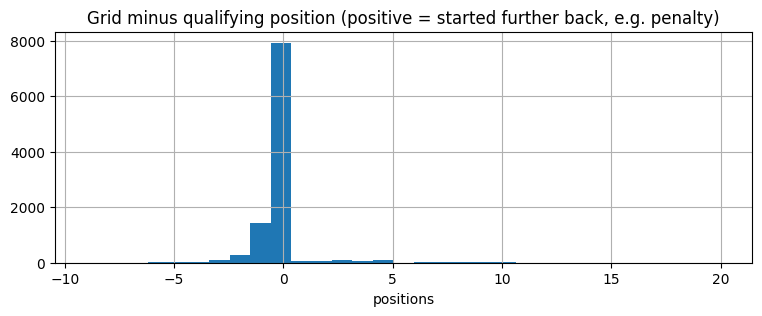

In [18]:
q = tables["qualifying"][["raceId", "driverId", "position"]].rename(columns={"position": "quali_pos"})
qg = tables["results"].merge(q, on=["raceId", "driverId"], how="inner")
qg = qg[qg["grid"] > 0]
diff = (qg["grid"] - qg["quali_pos"]).astype(float)
print(f"Rows with both values: {len(qg)} | grid differs from qualifying: {(diff != 0).mean():.1%} "
      f"| further back: {(diff > 0).mean():.1%} | further forward: {(diff < 0).mean():.1%}")
ax = diff.clip(-10, 20).hist(bins=31, figsize=(9, 3))
ax.set(title="Grid minus qualifying position (positive = started further back, e.g. penalty)", xlabel="positions")
plt.show()

### 5.3 Remaining grid = 0 rows and driver age

In [19]:
r = tables["results"]
g0 = r[r["grid"] == 0]
st = g0["statusId"].map(tables["status"].set_index("statusId")["status"])
yr = g0["raceId"].map(race_year(tables))
print(f"grid = 0 rows kept: {len(g0)} | from 2000 onward: {(yr >= 2000).sum()}")
print("Most common statuses:", st.value_counts().head(6).to_dict())

age = (r[["raceId", "driverId"]]
       .merge(tables["races"][["raceId", "date"]], on="raceId")
       .merge(tables["drivers"][["driverId", "dob"]], on="driverId"))
age = (age["date"] - age["dob"]).dt.days / 365.25
add_checks("results (final)", {"driver age < 17": (age < 17).sum(), "driver age > 60": (age > 60).sum(),
                               "driver age missing": age.isna().sum()})
print(f"Age range: {age.min():.1f}–{age.max():.1f} years")

grid = 0 rows kept: 87 | from 2000 onward: 73
Most common statuses: {'+1 Lap': 27, 'Finished': 22, '+2 Laps': 7, 'Disqualified': 6, 'Excluded': 6, 'Retired': 3}
driver age < 17       0
driver age > 60       0
driver age missing    0
Age range: 17.5–55.8 years


### 5.4 Qualifying findings

In [20]:
q = tables["qualifying"].merge(tables["races"][["raceId", "year", "name"]], on="raceId")
print("Seasons before 2006 with a Q2 time:", q.loc[(q["year"] < 2006) & q["q2"].notna(), "year"].value_counts().sort_index().to_dict())

miss_q3 = q[(q["year"] >= 2006) & (q["position"] <= 10) & q["q3"].isna()]
per_race = miss_q3.groupby(["year", "name"]).size()
print(f"Top-10 qualifiers without a Q3 time: {len(miss_q3)} | in races where Q3 had (almost) no times: "
      f"{int(per_race[per_race >= 8].sum())} rows in {int((per_race >= 8).sum())} races")

# extreme Q1 times
quali = tables["qualifying"]
best = quali.groupby("raceId")["q1"].transform("min")
bad_q1 = (quali["q1"] / best > 1.5) | (quali["q1"] < 50) | (quali["q1"] > 200)
print("\nExtreme Q1 times (before the fix):")
display(q.loc[bad_q1.values, ["year", "name", "driverId", "position", "q1"]])

quali.loc[bad_q1, "q1"] = np.nan
tables["qualifying"] = quali
log_step("4_bad_q1", "qualifying", len(quali), len(quali),
         f"{int(bad_q1.sum())} impossible Q1 time(s) set to NaN (row kept)")

best = tables["qualifying"].groupby("raceId")["q1"].transform("min")
print("Extreme Q1 times left after the fix:", int((tables["qualifying"]["q1"] / best > 1.5).sum()))

Seasons before 2006 with a Q2 time: {np.int64(2005): 107}
Top-10 qualifiers without a Q3 time: 123 | in races where Q3 had (almost) no times: 10 rows in 1 races

Extreme Q1 times (before the fix):


,year,name,driverId,position,q1
2567,1995,Japanese Grand Prix,87,24,1002.64


Extreme Q1 times left after the fix: 0


### 5.5 Pit-stop gaps and standings codes

In [21]:
ps = tables["pit_stops"].copy()
g = ps.groupby(["raceId", "driverId"])["stop"].agg(["min", "max", "count"])
gaps = g[(g["min"] != 1) | (g["max"] != g["count"])].join(race_year(tables).rename("year"), on="raceId")
print(f"Driver-races with gaps in stop numbers (before the fix): {len(gaps)}")
display(gaps)

# renumber stops by lap
grp = ps.groupby(["raceId", "driverId"])["stop"]
wrong = (grp.transform("min") == 1) & (grp.transform("max") > grp.transform("count"))
new_stop = ps[wrong].sort_values(["raceId", "driverId", "lap"]).groupby(["raceId", "driverId"]).cumcount() + 1
ps.loc[new_stop.index, "stop"] = new_stop.astype("Int64")
tables["pit_stops"] = ps
assert not ps.duplicated(["raceId", "driverId", "stop"]).any(), "renumbering created duplicate keys"
n_fixed = ps.loc[wrong, ["raceId", "driverId"]].drop_duplicates().shape[0]
log_step("4_pit_stop_numbers", "pit_stops", len(ps), len(ps),
         f"stop numbers renumbered by lap order in {n_fixed} driver-races (row count unchanged)")

g2 = ps.groupby(["raceId", "driverId"])["stop"].agg(["min", "max", "count"])
left = g2[(g2["min"] != 1) | (g2["max"] != g2["count"])].join(race_year(tables).rename("year"), on="raceId")
print(f"Renumbered: {n_fixed} driver-races | gaps left (first stop missing, kept): {len(left)}")
display(left)

# standings codes
cons = tables["constructors"].set_index("constructorId")["name"]
drv = tables["drivers"].set_index("driverId")[["forename", "surname"]].agg(" ".join, axis=1)
ry = race_year(tables)
cs, cr, ds = tables["constructor_standings"], tables["constructor_results"], tables["driver_standings"]
print("Constructor standings with code E:",
      cs.loc[cs["positionText"] == "E"].assign(team=lambda d: d["constructorId"].map(cons), year=lambda d: d["raceId"].map(ry))
        [["year", "team"]].value_counts().to_dict())
print("Constructor results with status D:",
      cr.loc[cr["status"] == "D"].assign(team=lambda d: d["constructorId"].map(cons), year=lambda d: d["raceId"].map(ry))
        [["year", "team"]].value_counts().to_dict())
print("Driver standings with code D:",
      ds.loc[ds["positionText"] == "D"].assign(driver=lambda d: d["driverId"].map(drv), year=lambda d: d["raceId"].map(ry))
        [["year", "driver"]].value_counts().to_dict())

Driver-races with gaps in stop numbers (before the fix): 8


min  max  count  year
raceId driverId                       
908    820         2    3      2  2014
1024   832         2    2      1  2019
1128   1           1   51      2  2024
       822         1   15      2  2024
       830         1   52      2  2024
       840         1   48      3  2024
       855         1   70      2  2024
       858         1   57      2  2024

Renumbered: 6 driver-races | gaps left (first stop missing, kept): 2


,,min,max,count,year
raceId,driverId,,,,
908,820,2,3,2,2014
1024,832,2,2,1,2019


Constructor standings with code E: {(2007, 'McLaren'): 17}
Constructor results with status D: {(2007, 'McLaren'): 17}
Driver standings with code D: {(1997, 'Michael Schumacher'): 1}


## 6. After-cleaning EDA

### 6.1 Cleaning funnel

,step,table,rows_before,rows_after,removed,reason
0,1_indy500,constructor_results,12625,12604,21,Indianapolis 500 excluded
1,1_indy500,constructor_standings,13391,13365,26,Indianapolis 500 excluded
2,1_indy500,driver_standings,34863,34194,669,Indianapolis 500 excluded
3,1_indy500,races,1125,1114,11,Indianapolis 500 excluded
4,1_indy500,results,26759,26354,405,Indianapolis 500 excluded
5,2_non_starters,results,26354,24630,1724,did not qualify / did not pre-qualify / 107% r...
6,3_grain,results,24630,24566,64,"duplicate (raceId, driverId): keep the started..."
7,4_bad_q1,qualifying,10494,10494,0,1 impossible Q1 time(s) set to NaN (row kept)
8,4_pit_stop_numbers,pit_stops,11371,11371,0,stop numbers renumbered by lap order in 6 driv...


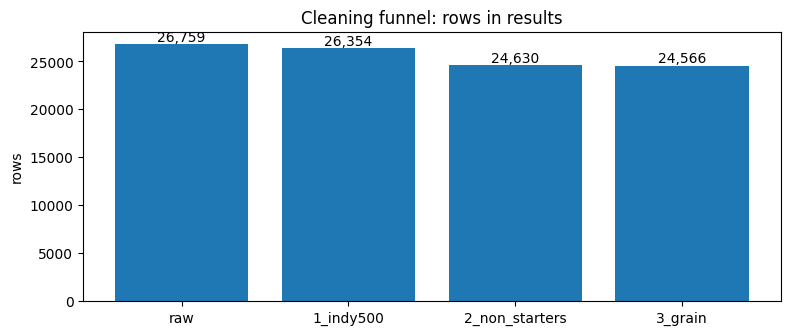

In [22]:
funnel = pd.DataFrame(cleaning_log)
display(funnel)
res_steps = funnel[funnel["table"] == "results"]
counts = [len(raw_tables["results"])] + res_steps["rows_after"].tolist()
labels = ["raw"] + res_steps["step"].tolist()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(labels, counts)
for i, c in enumerate(counts):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom")
ax.set(title="Cleaning funnel: rows in results", ylabel="rows"); plt.show()

### 6.2 Era profile before vs after

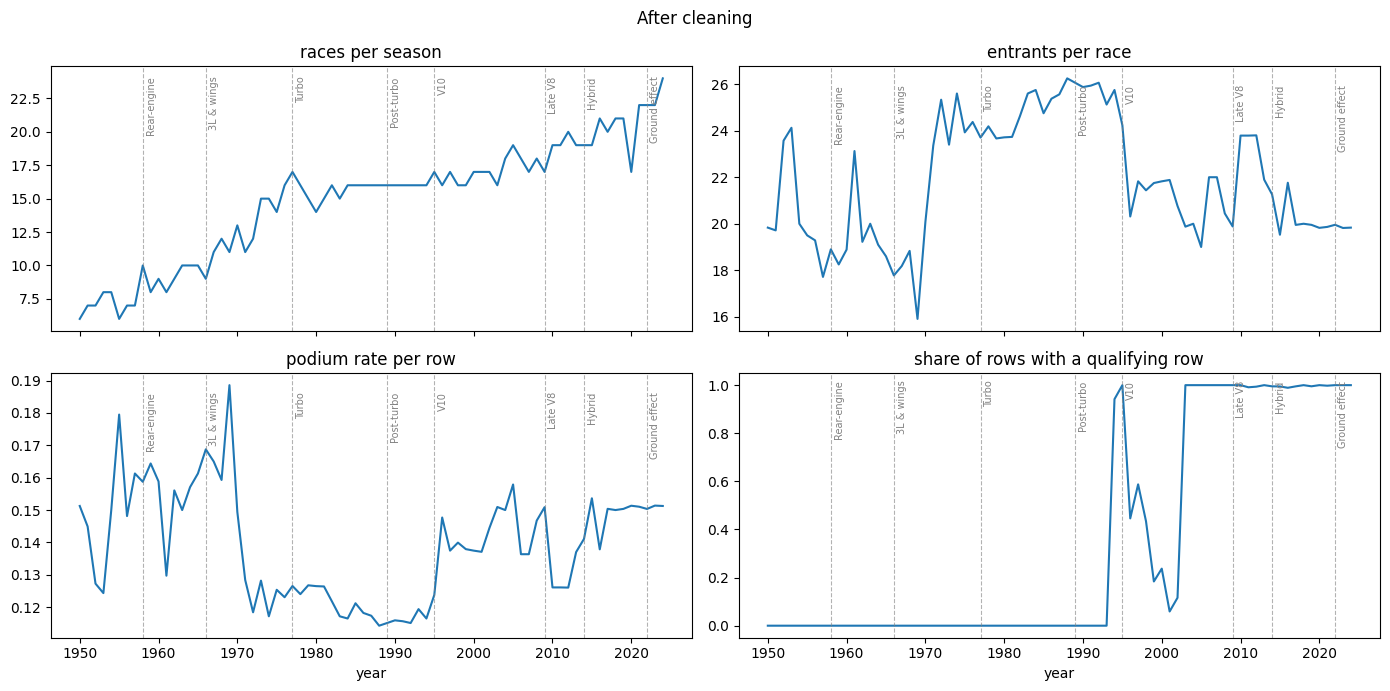

,races_before,rows_before,podium_rate_before,quali_coverage_before,rows_per_race_before,races_after,rows_after,podium_rate_after,quali_coverage_after,rows_per_race_after
era,,,,,,,,,,
1950–57,64,1571,0.136,0.000,24.547,56,1151,0.146,0.000,20.554
1958–65,77,1768,0.131,0.000,22.961,74,1440,0.154,0.000,19.459
1966–76,139,3237,0.129,0.000,23.288,139,3043,0.137,0.000,21.892
1977–88,188,5234,0.108,0.000,27.840,188,4654,0.121,0.000,24.755
1989–94,96,3035,0.095,0.129,31.615,96,2477,0.116,0.157,25.802
1995–2008,239,5138,0.140,0.652,21.498,239,5072,0.141,0.654,21.222
2009–13,94,2150,0.131,0.996,22.872,94,2134,0.132,0.997,22.702
2014–21,160,3267,0.147,0.995,20.419,160,3244,0.148,0.996,20.275
2022–24,68,1359,0.150,1.000,19.985,68,1351,0.151,1.000,19.868


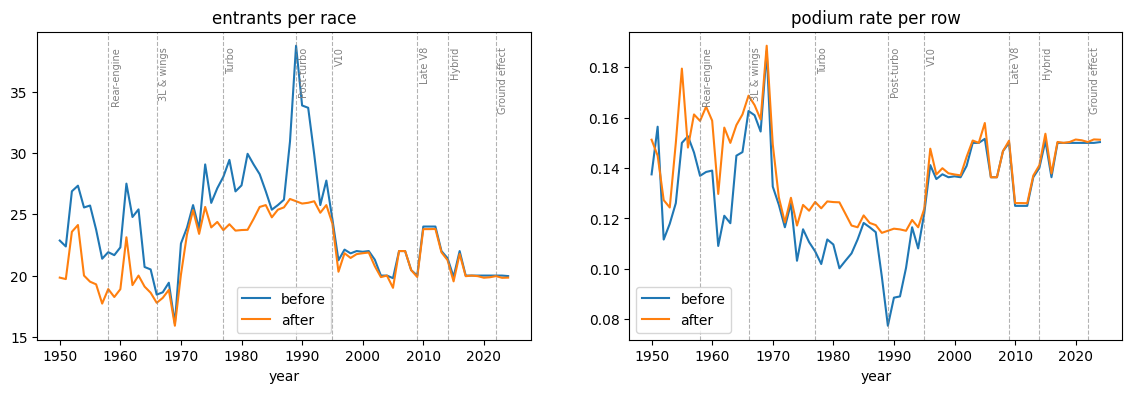

In [23]:
after_year, after_era = era_profile(tables, "After cleaning")
display(before_era.join(after_era, lsuffix="_before", rsuffix="_after"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["entrants per race", "podium rate per row"]):
    before_year[col].plot(ax=ax, label="before"); after_year[col].plot(ax=ax, label="after")
    ax.set_title(col); ax.legend(); add_eras(ax)
plt.show()

### 6.3 Data coverage by table and season

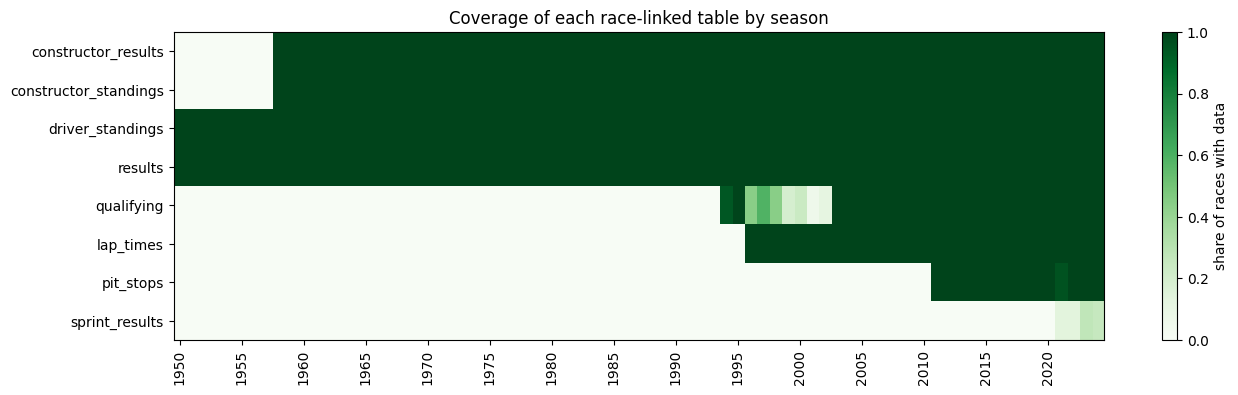

,first season,first season >= 90%
driver_standings,1950,1950.0
results,1950,1950.0
constructor_results,1958,1958.0
constructor_standings,1958,1958.0
qualifying,1994,1994.0
lap_times,1996,1996.0
pit_stops,2011,2011.0
sprint_results,2021,NaN


In [24]:
def coverage_by_season(tbls):
    ry = tbls["races"][["raceId", "year"]]
    cov = {}
    for name, df in tbls.items():
        if "raceId" in df.columns and name != "races":
            has = ry["raceId"].isin(df["raceId"].dropna().unique()).astype(float)
            cov[name] = has.groupby(ry["year"].astype(int)).mean()
    return pd.DataFrame(cov).T.astype(float)

cov = coverage_by_season(tables)
fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(cov.to_numpy(dtype=float), aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_yticks(range(len(cov))); ax.set_yticklabels(cov.index)
xt = list(range(0, cov.shape[1], 5))
ax.set_xticks(xt); ax.set_xticklabels(cov.columns[xt], rotation=90)
plt.colorbar(im, label="share of races with data"); ax.set_title("Coverage of each race-linked table by season")
plt.show()

first = pd.Series({t: cov.columns[cov.loc[t] > 0].min() for t in cov.index}, name="first season").sort_values()
full = pd.Series({t: cov.columns[cov.loc[t] >= 0.9].min() for t in cov.index}, name="first season >= 90%")
pd.concat([first, full], axis=1)

### 6.4 Before vs after, per table

,rows_raw,rows_clean,placeholders_raw,nan_after_typing,text_cols_raw,text_cols_clean
table,,,,,,
circuits,77,77,0,0,9,5
constructors,212,212,0,0,5,4
constructor_results,12625,12604,12608,12608,5,1
constructor_standings,13391,13365,0,0,7,1
drivers,861,861,1559,1559,9,6
driver_standings,34863,34194,0,0,7,1
races,1125,1114,11349,11349,18,2
results,26759,24566,122887,122887,18,2
qualifying,10494,10494,11668,11668,9,0


Tables where NaN after typing != placeholders before: none


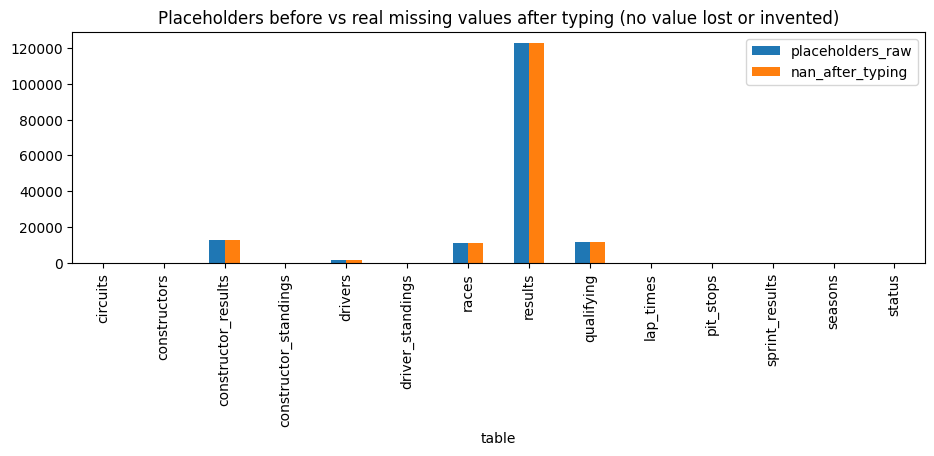

In [25]:
rows = []
for t in TABLE_NAMES:
    r, v, c = raw_tables[t], value_clean[t], tables[t]
    rows.append(dict(table=t, rows_raw=len(r), rows_clean=len(c),
                     placeholders_raw=int(r.isin(SENTINELS).sum().sum()),
                     nan_after_typing=int(v.isna().sum().sum()),
                     text_cols_raw=int(sum(is_text(r[col]) for col in r.columns)),
                     text_cols_clean=int(sum(is_text(c[col]) for col in c.columns))))
summary = pd.DataFrame(rows).set_index("table")
display(summary)

mism = summary[summary["placeholders_raw"] != summary["nan_after_typing"]]
print("Tables where NaN after typing != placeholders before:", list(mism.index) or "none")
summary[["placeholders_raw", "nan_after_typing"]].plot(kind="bar", figsize=(11, 3),
        title="Placeholders before vs real missing values after typing (no value lost or invented)")
plt.show()

## 7. Data dictionary, final checks and saving

### 7.1 Missing values: kept as NaN, with the reason

In [26]:
pd.DataFrame(missing_notes)

,table,column,kind,reason
0,races,time,unknown,race start time not recorded before 2005
1,races,fp*/quali*/sprint* date & time,structural,session schedule only recorded from 2021; empt...
2,qualifying,q2/q3,structural,before 2006 the session did not exist (Q2 only...
3,qualifying,"q3 (top 10, 2006+)",unknown,reached Q3 (or Q3 not held) but no lap time
4,qualifying,q1,unknown,no time set / not recorded (drivers start from...
5,lap_times,(whole table),structural,lap-by-lap timing only exists from 1996
6,pit_stops,(whole table),structural,pit-stop data only exists from 2011
7,constructor_results,status,structural,only filled ('D') when the constructor was dis...
8,drivers,number / code,structural,permanent numbers (2014) and 3-letter codes on...
9,results,position,structural,empty when the driver was not classified (posi...


### 7.2 Leakage dictionary

In [27]:
leak = pd.DataFrame(leakage_rows).drop_duplicates(["table", "column"])
print(leak["availability"].value_counts().to_dict())
leak

{'pre-race': 37, 'post-race': 35, 'identifier': 18, 'pre-race (team decision)': 13, 'not used': 9, 'target': 1}


,table,column,availability,note
0,races,raceId,identifier,key
1,races,year,pre-race,race calendar is known in advance
2,races,round,pre-race,race calendar is known in advance
3,races,circuitId,pre-race,race calendar is known in advance
4,races,name,pre-race,race calendar is known in advance
...,...,...,...,...
108,sprint_results,time,pre-race (team decision),"the sprint (2021+) runs BEFORE the main race, ..."
109,sprint_results,milliseconds,pre-race (team decision),"the sprint (2021+) runs BEFORE the main race, ..."
110,sprint_results,fastestLap,pre-race (team decision),"the sprint (2021+) runs BEFORE the main race, ..."
111,sprint_results,fastestLapTime,pre-race (team decision),"the sprint (2021+) runs BEFORE the main race, ..."


In [28]:
pd.DataFrame(validation_reports)

,table,check,violations
0,races,date year differs from year column,0
1,races,seasons with gaps/repeats in round numbers,0
2,races,seasons where round order differs from date order,0
3,races,races with no result rows,0
4,qualifying,knockout-era top-10 without Q3 time,123
5,qualifying,races with gaps/repeats in qualifying position,0
6,qualifying,q1 outside 50-200 s,1
7,qualifying,q1 more than 50% slower than session best,1
8,lap_times,parsed time differs from milliseconds by > 0.01 s,0
9,lap_times,lap number < 1,0


### 7.3 Final assertions

In [29]:
final_fk = []
for child, col, parent in [
        ("races", "circuitId", "circuits"), ("races", "year", "seasons"),
        ("results", "raceId", "races"), ("results", "driverId", "drivers"),
        ("results", "constructorId", "constructors"), ("results", "statusId", "status"),
        ("sprint_results", "raceId", "races"), ("sprint_results", "driverId", "drivers"),
        ("sprint_results", "statusId", "status"),
        ("qualifying", "raceId", "races"), ("qualifying", "driverId", "drivers"),
        ("qualifying", "constructorId", "constructors"),
        ("lap_times", "raceId", "races"), ("lap_times", "driverId", "drivers"),
        ("pit_stops", "raceId", "races"), ("pit_stops", "driverId", "drivers"),
        ("driver_standings", "raceId", "races"), ("driver_standings", "driverId", "drivers"),
        ("constructor_standings", "raceId", "races"), ("constructor_standings", "constructorId", "constructors"),
        ("constructor_results", "raceId", "races"), ("constructor_results", "constructorId", "constructors")]:
    check_fk(tables, child, col, parent, report=final_fk)
final_fk = pd.DataFrame(final_fk)
assert final_fk["orphans"].sum() == 0, final_fk[final_fk["orphans"] > 0]

PK = {"circuits": ["circuitId"], "constructors": ["constructorId"], "drivers": ["driverId"],
      "races": ["raceId"], "seasons": ["year"], "status": ["statusId"], "results": ["resultId"],
      "sprint_results": ["resultId"], "qualifying": ["qualifyId"], "lap_times": ["raceId", "driverId", "lap"],
      "pit_stops": ["raceId", "driverId", "stop"], "driver_standings": ["driverStandingsId"],
      "constructor_standings": ["constructorStandingsId"], "constructor_results": ["constructorResultsId"]}
for t, k in PK.items():
    assert tables[t][k].notna().all().all() and not tables[t].duplicated(k).any(), f"{t}: primary key problem"

r = tables["results"]
assert not r.duplicated(["raceId", "driverId"]).any(), "grain broken"
assert not r["raceId"].isin(SHARED["INDY_IDS"]).any(), "Indianapolis 500 still present"
assert not r["positionText"].isin(NON_START_CODES).any(), "non-starters still present"
assert r[["raceId", "driverId", "constructorId", "grid", "positionOrder", "statusId"]].notna().all().all()
assert str(tables["races"]["date"].dtype).startswith("datetime64")
assert tables["lap_times"]["time"].dtype == float and tables["qualifying"]["q1"].dtype == float
print(f"All checks passed: {len(PK)} primary keys, {len(final_fk)} foreign keys, grain unique "
      f"({len(r):,} driver–race rows), {r['raceId'].nunique():,} races.")

All checks passed: 14 primary keys, 22 foreign keys, grain unique (24,566 driver–race rows), 1,114 races.


### 7.4 Save the clean tables

In [30]:
OUT = "/kaggle/working/clean/" if os.path.exists("/kaggle/working") else "clean/"
os.makedirs(OUT, exist_ok=True)
try:
    for name, df in tables.items():
        df.to_parquet(OUT + f"{name}.parquet", index=False)
    fmt = "parquet"
except Exception as e:                                 # fallback to CSV
    for name, df in tables.items():
        df.to_csv(OUT + f"{name}.csv", index=False)
    fmt = f"csv ({type(e).__name__})"
print(f"Saved {len(tables)} clean tables to {OUT} as {fmt}")

Saved 15 clean tables to clean/ as parquet
